# Predicting Customer Churn - Basic EDA
This is an EDA notebook for Kaggle's playground March 2026 competition, "Predicting Customer Churn". This basic EDA is the first EDA I perform in every tabular data competition. It shows:
* is column Categorical or Numeric
* how many unique values per column
* how many nan values per column
* distribution of column values
* relationship between column and target
* distribution of target

There is a discussion about advanced EDA techniques [here][1]

[1]: https://www.kaggle.com/competitions/playground-series-s6e3/discussion/680290

# Load Train Data

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

train = pd.read_csv("/kaggle/input/competitions/playground-series-s6e3/train.csv")
print(f"Train shape: {train.shape}")
train.head()

Train shape: (594194, 21)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


# Basic EDA Function
The following function was written by ChatGPT 5.2. It plots the relationship between features and target. And it plots the distrubtion of feature values. These insights can help us build models.

In [2]:
def plot_features_dual_axis(
    df: pd.DataFrame,
    cols: list[str],
    target_col: str,
    n_bins: int = 10,
    n_wide: int = 3,
    figsize_per_plot: tuple[float, float] = (5, 4),
    int_as_cat_unique_max: int | None = 20,
    cat_order: dict[str, list] | None = None,   # <-- NEW
):
    BAR_COLOR = "tab:blue"
    LINE_COLOR = "tab:orange"

    def is_categorical(s: pd.Series) -> bool:
        return s.dtype == "object" or pd.api.types.is_string_dtype(s)

    n_cols = len(cols)
    n_rows = int(np.ceil(n_cols / n_wide))

    fig, axes = plt.subplots(
        n_rows,
        n_wide,
        figsize=(figsize_per_plot[0] * n_wide, figsize_per_plot[1] * n_rows),
    )

    axes = np.atleast_1d(axes).ravel()

    for i, col in enumerate(cols):
        ax1 = axes[i]
        col_safe = col.replace("_", r"\_")

        n_nan = df[col].isna().sum()
        n_unique = df[col].nunique(dropna=True)

        tmp = df[[col, target_col]].dropna()
        if tmp.empty:
            ax1.set_title(
                rf"$\bf{{{col_safe}}}$"
                f"\n(empty after dropna; {n_unique} unique, {n_nan} nan)"
            )
            continue

        x = tmp[col]
        y = tmp[target_col]

        # ---------- TRUE CATEGORICAL ----------
        if is_categorical(x):
            type_str = "categorical"

            # base counts / means
            counts = x.value_counts()
            mean_y = tmp.groupby(col)[target_col].mean()

            # ---- APPLY USER-DEFINED CATEGORY ORDER (if provided) ----
            if cat_order is not None and col in cat_order:
                desired = list(cat_order[col])

                # keep only categories present in data
                ordered = [c for c in desired if c in counts.index]

                # append any remaining categories not specified by user
                remaining = [c for c in counts.index if c not in ordered]
                final_order = ordered + remaining
            else:
                final_order = sorted(counts.index)

            counts = counts.loc[final_order]
            mean_y = mean_y.loc[final_order]

            xpos = np.arange(len(final_order))

            ax1.bar(xpos, counts.values, alpha=0.6, color=BAR_COLOR)
            ax1.set_xlabel(col)
            ax1.set_ylabel("Count", color=BAR_COLOR)
            ax1.tick_params(axis="y", colors=BAR_COLOR)

            ax1.set_xticks(xpos)
            ax1.set_xticklabels(final_order, rotation=45, ha="right")

            ax2 = ax1.twinx()
            ax2.plot(xpos, mean_y.values, marker="o", color=LINE_COLOR)
            ax2.set_ylabel(f"Mean {target_col}", color=LINE_COLOR)
            ax2.tick_params(axis="y", colors=LINE_COLOR)

            ax1.set_title(
                rf"$\bf{{{col_safe}}}$: Count vs Mean {target_col}"
                f"\n({type_str} with {n_unique} unique and {n_nan} nan)"
            )

        # ---------- NUMERIC ----------
        else:
            type_str = "numeric"

            xvals = x.values
            yvals = y.values

            mask = np.isfinite(xvals) & np.isfinite(yvals)
            xvals = xvals[mask]
            yvals = yvals[mask]

            if len(xvals) == 0:
                ax1.set_title(
                    rf"$\bf{{{col_safe}}}$"
                    f"\n({type_str} with {n_unique} unique and {n_nan} nan)"
                )
                continue

            unique_vals = np.sort(np.unique(xvals))
            n_unique_eff = len(unique_vals)

            # --- Case 1: int-as-categorical ---
            if int_as_cat_unique_max is not None and n_unique_eff <= int_as_cat_unique_max:
                counts = np.array([(xvals == v).sum() for v in unique_vals])
                mean_y = np.array([yvals[xvals == v].mean() for v in unique_vals])

                xpos = np.arange(n_unique_eff)

                ax1.bar(xpos, counts, alpha=0.6, color=BAR_COLOR)
                ax1.set_xlabel(col)
                ax1.set_ylabel("Count", color=BAR_COLOR)
                ax1.tick_params(axis="y", colors=BAR_COLOR)

                rotate = 45 if n_unique_eff > n_bins else 0
                step = max(int(np.ceil(n_unique_eff / n_bins)), 1)
                tick_idx = np.arange(0, n_unique_eff, step)

                if pd.api.types.is_integer_dtype(x):
                    tick_labels = unique_vals[tick_idx].astype(int)
                else:
                    tick_labels = unique_vals[tick_idx]

                ax1.set_xticks(tick_idx)
                ax1.set_xticklabels(
                    tick_labels,
                    rotation=rotate,
                    ha="right" if rotate else "center",
                )

                ax2 = ax1.twinx()
                ax2.plot(xpos, mean_y, marker="o", color=LINE_COLOR)
                ax2.set_ylabel(f"Mean {target_col}", color=LINE_COLOR)
                ax2.tick_params(axis="y", colors=LINE_COLOR)

                ax1.set_title(
                    rf"$\bf{{{col_safe}}}$: Per-Value Count vs Mean {target_col}"
                    f"\n({type_str} with {n_unique} unique and {n_nan} nan)"
                )

            # --- Case 2: low-cardinality numeric bins ---
            elif n_unique_eff < n_bins:
                counts = np.array([(xvals == v).sum() for v in unique_vals])
                mean_y = np.array([yvals[xvals == v].mean() for v in unique_vals])

                width = 0.8 * (np.min(np.diff(unique_vals)) if n_unique_eff > 1 else 1.0)

                ax1.bar(unique_vals, counts, width=width, alpha=0.6, color=BAR_COLOR)
                ax1.set_xlabel(col)
                ax1.set_ylabel("Count", color=BAR_COLOR)
                ax1.tick_params(axis="y", colors=BAR_COLOR)

                ax2 = ax1.twinx()
                ax2.plot(unique_vals, mean_y, marker="o", color=LINE_COLOR)
                ax2.set_ylabel(f"Mean {target_col}", color=LINE_COLOR)
                ax2.tick_params(axis="y", colors=LINE_COLOR)

                ax1.set_title(
                    rf"$\bf{{{col_safe}}}$: Per-Value Count vs Mean {target_col}"
                    f"\n({type_str} with {n_unique} unique and {n_nan} nan)"
                )

            # --- Case 3: regular histogram ---
            else:
                bins = np.linspace(xvals.min(), xvals.max(), n_bins + 1)
                bin_centers = 0.5 * (bins[:-1] + bins[1:])

                counts, _ = np.histogram(xvals, bins=bins)
                bin_idx = np.digitize(xvals, bins) - 1

                mean_y = np.array([
                    yvals[bin_idx == j].mean() if np.any(bin_idx == j) else np.nan
                    for j in range(n_bins)
                ])

                ax1.bar(
                    bin_centers,
                    counts,
                    width=(bins[1] - bins[0]),
                    alpha=0.6,
                    color=BAR_COLOR,
                )
                ax1.set_xlabel(col)
                ax1.set_ylabel("Count", color=BAR_COLOR)
                ax1.tick_params(axis="y", colors=BAR_COLOR)

                ax2 = ax1.twinx()
                ax2.plot(bin_centers, mean_y, marker="o", color=LINE_COLOR)
                ax2.set_ylabel(f"Mean {target_col}", color=LINE_COLOR)
                ax2.tick_params(axis="y", colors=LINE_COLOR)

                ax1.set_title(
                    rf"$\bf{{{col_safe}}}$: Histogram vs Mean {target_col}"
                    f"\n({type_str} with {n_unique} unique and {n_nan} nan)"
                )

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

# Display Feature EDA
The target `Churn` takes the values `Yes` and `No`. We will create column `y` to be `1` when target is `Yes` and `0` when target is `No`. Then below, we will display the mean of `y` for different features. This will show us the relationship between features and target.

In [3]:
FEATURES = list( train.columns[1:-1] )
print(f"There are {len(FEATURES)} features:")
print(FEATURES)

There are 19 features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


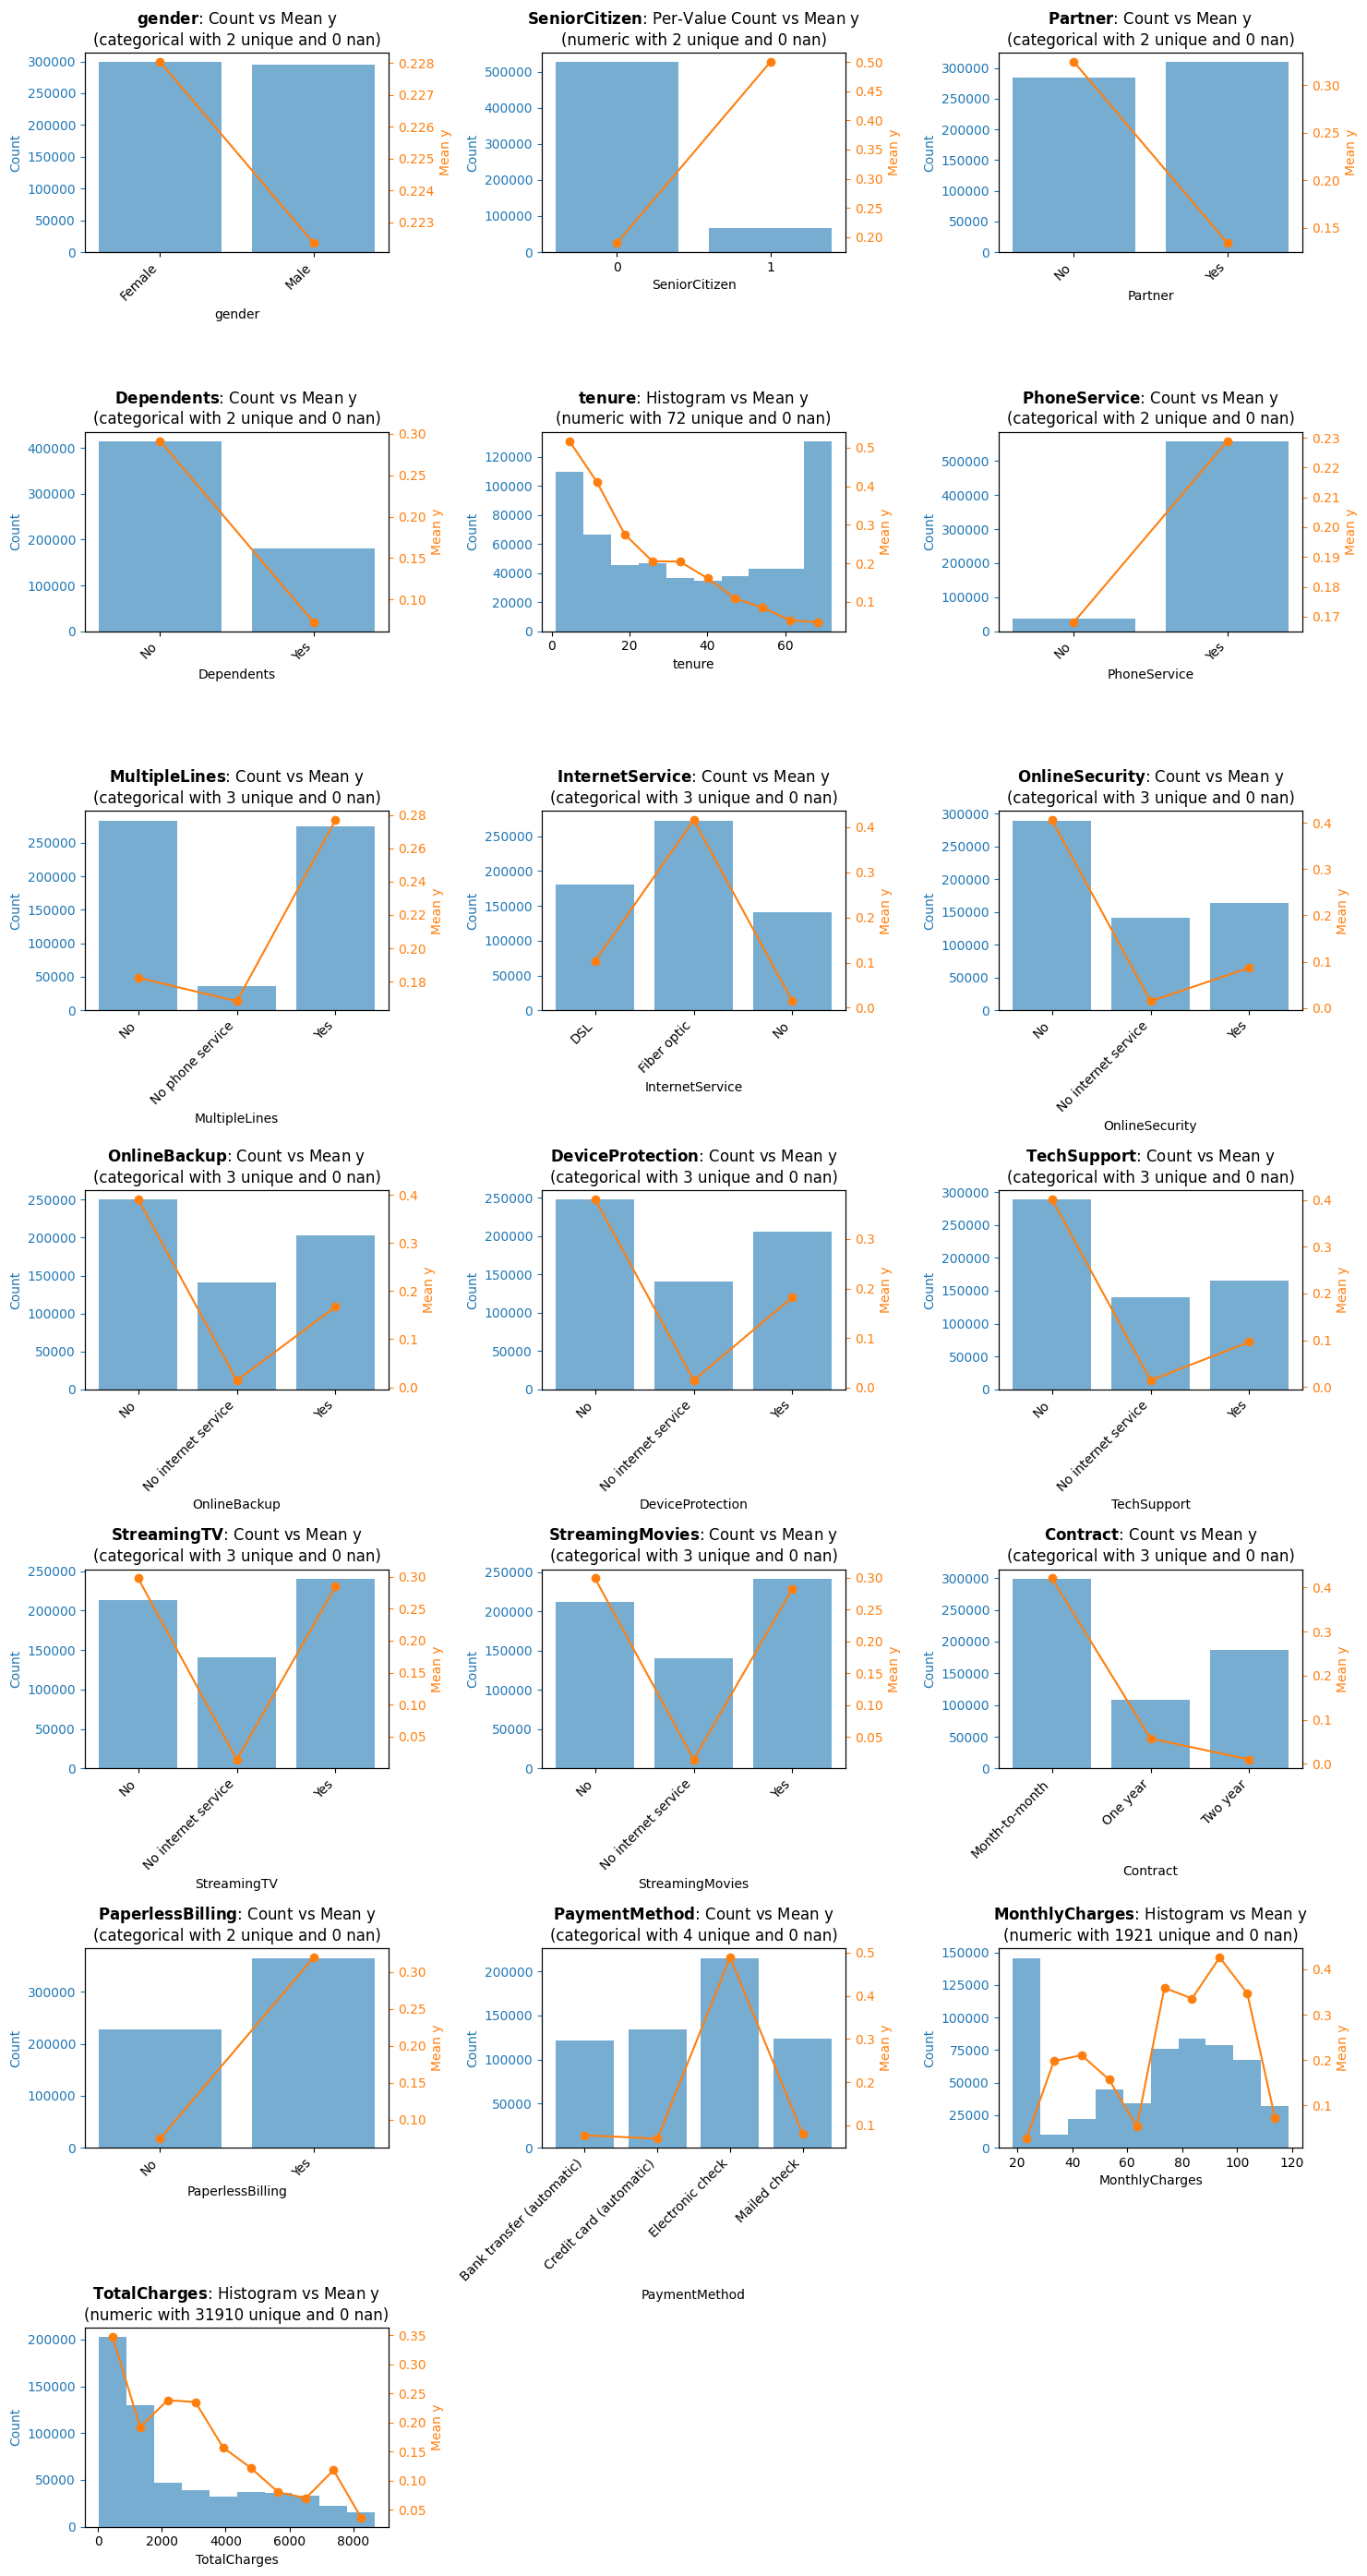

In [4]:
train['y'] = train["Churn"].map({"Yes":1,"No":0})

plot_features_dual_axis(
    train,
    cols=FEATURES,
    target_col="y",
    n_bins=10,
    n_wide=3,
    int_as_cat_unique_max=20,
    cat_order = {},
)

# Display Target EDA

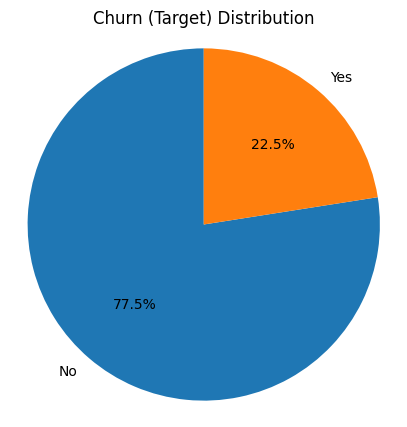

In [5]:
# Count values
counts = train["Churn"].value_counts()

# Plot pie chart
plt.figure(figsize=(5, 5))
plt.pie(
    counts,
    labels=counts.index,
    autopct="%.1f%%",      # Show percentages
    startangle=90
)

plt.title("Churn (Target) Distribution")
plt.axis("equal")  # Makes the pie circular

plt.show()

# Conclusions
From the above EDA we observe the following:
* We have 19 columns
* No columns have nan values
* 16 of 19 columns have 4 or less unique values and can be treated as categorical
* 3 of 19 numerics have 72, 2k, 32k respectively unique values and are numeric.
* We observe strong relationships between features and target.